# Three Failure Modes of Reward Composition

We reproduce three documented failure modes on the canonical 2D toy
from `src.scenarios.cot_drift`. The action space is `[0,1]^2` with
axes `action_quality` and `cot_content`. A ground-truth task reward
depends only on `action_quality`; a CoT-reading scorer assigns a
spurious bonus to a specific `cot_content` pattern.

Each failure mode is one paragraph and one figure.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from src.scenarios import cot_drift
from src.io_utils import seeded_path

plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})
SEED = 0

## 1. CoT drift

Under a vanilla weighted sum the policy is pulled off the
`action_quality` axis toward the CoT-content ridge (`cot_content`
near 0.6). The ground-truth task reward stays flat in the CoT axis,
but the policy distribution drifts anyway, because that direction
is where the LLM-judge gradient is steepest. This is the failure
mode the differential cap is designed to suppress.

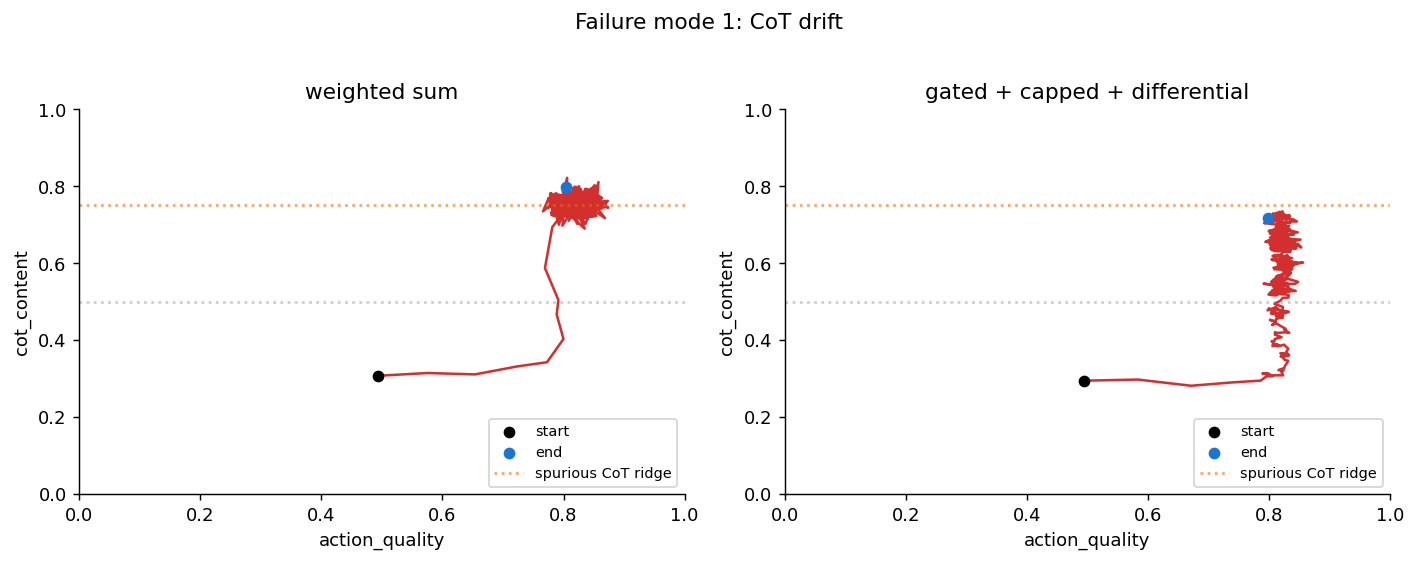

In [2]:
cfg = cot_drift.TrainConfig(n_steps=600, n_samples=64, seed=SEED)
h_ws = cot_drift.run_cot_drift('weighted_sum', cfg)
h_dc = cot_drift.run_cot_drift('gated_capped_differential', cfg, delta=0.05)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, h, title in [(axes[0], h_ws, 'weighted sum'),
                     (axes[1], h_dc, 'gated + capped + differential')]:
    mu = np.array(h.policy_mu)
    ax.plot(mu[:, 0], mu[:, 1], lw=1.4, color='#d32f2f')
    ax.scatter([mu[0, 0]], [mu[0, 1]], color='black', s=30, zorder=5, label='start')
    ax.scatter([mu[-1, 0]], [mu[-1, 1]], color='#1976d2', s=30, zorder=5, label='end')
    ax.axhline(0.5, color='gray', ls=':', alpha=0.4)
    ax.axhline(0.75, color='#ef6c00', ls=':', alpha=0.6, label='spurious CoT ridge')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('action_quality'); ax.set_ylabel('cot_content')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('Failure mode 1: CoT drift', y=1.02)
fig.tight_layout()
fig.savefig(seeded_path('01_cot_drift', SEED), bbox_inches='tight')
plt.show()

## 2. Priority inversion (legacy 1D bandit)

The Med-RLVR direct-answer-hacking finding (Zhang et al., 2025).
Format compliance is treated as an additive scorer and creates a
local maximum that traps the policy. The fix is to make it a gate.

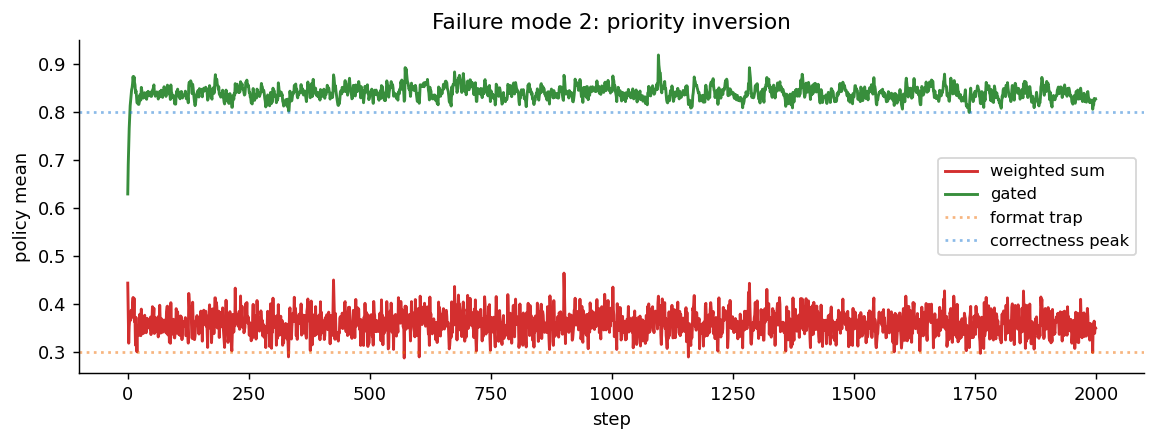

In [3]:
from src.composition import GatedCompositor, WeightedSumCompositor, run_bandit
from src.scenarios import priority_inversion_broken, priority_inversion_fixed

h_broken = run_bandit(WeightedSumCompositor(priority_inversion_broken()),
                      n_steps=2000, seed=SEED)
h_fixed  = run_bandit(GatedCompositor(priority_inversion_fixed(), monitor=False),
                      n_steps=2000, seed=SEED)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(h_broken['policy_mu'], color='#d32f2f', lw=1.6, label='weighted sum')
ax.plot(h_fixed['policy_mu'],  color='#388e3c', lw=1.6, label='gated')
ax.axhline(0.3, color='#ef6c00', ls=':', alpha=0.5, label='format trap')
ax.axhline(0.8, color='#1976d2', ls=':', alpha=0.5, label='correctness peak')
ax.set_xlabel('step'); ax.set_ylabel('policy mean')
ax.set_title('Failure mode 2: priority inversion')
ax.legend(fontsize=9, loc='center right')
fig.tight_layout()
fig.savefig(seeded_path('01_priority_inversion', SEED), bbox_inches='tight')
plt.show()

## 3. Seesaw exploitation (gradient dominance)

A high-variance LLM judge swamps the gradient even at low nominal
weight. Bounding each scorer's contribution restores balance.

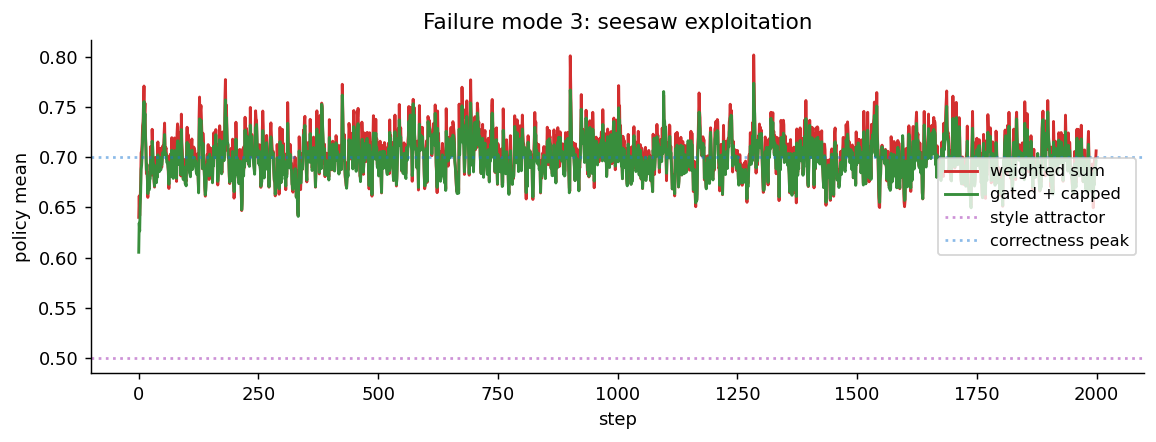

In [4]:
from src.scenarios import gradient_dominance_broken, gradient_dominance_fixed
rng = np.random.RandomState(SEED)
h_broken = run_bandit(WeightedSumCompositor(gradient_dominance_broken(rng)),
                      n_steps=2000, seed=SEED)
rng = np.random.RandomState(SEED)
h_fixed  = run_bandit(GatedCompositor(gradient_dominance_fixed(rng), monitor=False),
                      n_steps=2000, seed=SEED)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(h_broken['policy_mu'], color='#d32f2f', lw=1.6, label='weighted sum')
ax.plot(h_fixed['policy_mu'],  color='#388e3c', lw=1.6, label='gated + capped')
ax.axhline(0.5, color='#9c27b0', ls=':', alpha=0.5, label='style attractor')
ax.axhline(0.7, color='#1976d2', ls=':', alpha=0.5, label='correctness peak')
ax.set_xlabel('step'); ax.set_ylabel('policy mean')
ax.set_title('Failure mode 3: seesaw exploitation')
ax.legend(fontsize=9, loc='center right')
fig.tight_layout()
fig.savefig(seeded_path('01_seesaw', SEED), bbox_inches='tight')
plt.show()

Three failure modes, three concrete fixes. The next notebook puts
them side by side as a single comparison.